In [1]:
# importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,classification_report,log_loss,roc_auc_score

Confusion Matrix : 
 [[4 1]
 [1 4]]


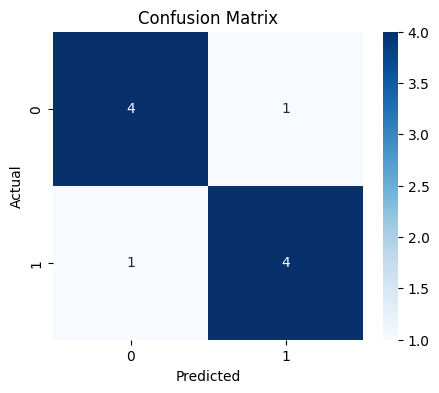

In [2]:
# lets prepare simple dataset
y_true = [1,0,1,1,0,1,0,0,1,0]
y_pred = [1,0,1,0,0,1,1,0,1,0]


# confusion matrix
cm = confusion_matrix(y_true,y_pred)
print("Confusion Matrix : \n",cm)  
# Visualizing confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show() 

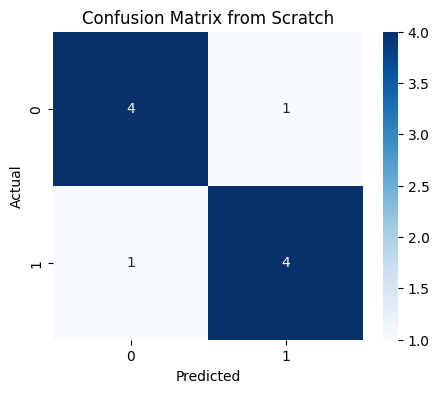

In [3]:
# lets implment confusion matrix from scratch
def confusion_matrix_scratch(y_true,y_pred):
    TP = FP = TN = FN = 0
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            TP += 1
        elif y_true[i] == 0 and y_pred[i] == 0:
            TN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
    return np.array([[TP,FP],[FN,TN]])

cm_scratch = confusion_matrix_scratch(y_true,y_pred)

# plot it 
plt.figure(figsize=(5,4))
sns.heatmap(cm_scratch,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix from Scratch')
plt.show()

In [4]:
# precision
precision = precision_score(y_true,y_pred)
print("Precision : ",precision)

# recall
recall = recall_score(y_true,y_pred)
print("Recall : ",recall)
# f1 score
f1 = f1_score(y_true,y_pred)
print("F1 Score : ",f1)

Precision :  0.8
Recall :  0.8
F1 Score :  0.8


In [5]:
classification_report = classification_report(y_true,y_pred)
print("Classification Report : \n",classification_report)

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



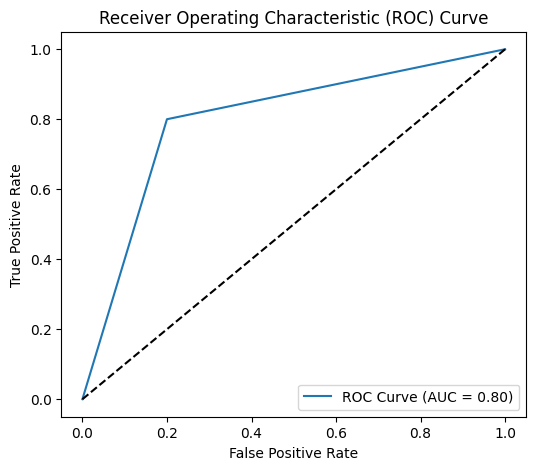

In [6]:
from sklearn.metrics import roc_curve,roc_auc_score
# ROC curve
fpr,tpr,thresholds = roc_curve(y_true,y_pred)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label='ROC Curve (AUC = %0.2f)' % roc_auc_score(y_true,y_pred))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [8]:
# log loss
# data preparation
y_true = [1,0,1,1,0,1,0,0,1,0]
y_pred_prob = [0.9,0.1,0.8,0.4,0.2,0.7,0.6,0.3,0.9,0.1]
y_pred_prob_m2 = [0.6,0.4,0.6,0.4,0.2,0.7,0.6,0.3,0.9,0.9]
from sklearn.metrics import log_loss
logloss = log_loss(y_true,y_pred_prob)
print("Log Loss : ",logloss)

log_loss_m2 = log_loss(y_true,y_pred_prob_m2)
# plot it 
print("Log Loss : ",log_loss_m2)


Log Loss :  0.34136605168855
Log Loss :  0.6709497382889829


Mean Absolute Error from Scratch :  0.5
Root Mean Squared Error from Scratch :  0.6123724356957945
Mean Absolute Percentage Error from Scratch :  32.73809523809524


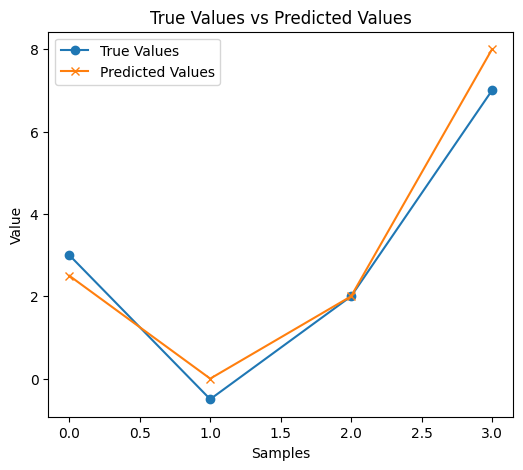

In [9]:
# regression
# data preparation
y_true_reg = [3.0, -0.5, 2.0, 7.0]
y_pred_reg = [2.5, 0.0, 2.0, 8.0]

# mean absolute error from scratch
def mae_scratch(y_true,y_pred):
    n = len(y_true)
    mae = sum(abs(y_true[i]-y_pred[i]) for i in range(n))/n
    return mae


# root mean squared error from scratch
def rmse_scratch(y_true,y_pred):
    n = len(y_true)
    rmse = np.sqrt(sum((y_true[i]-y_pred[i])**2 for i in range(n))/n)
    return rmse

# mean absolute % error from scratch
def mape_scratch(y_true,y_pred):
    n = len(y_true)
    mape = sum(abs((y_true[i]-y_pred[i])/y_true[i]) for i in range(n))/n * 100
    return mape

mae = mae_scratch(y_true_reg,y_pred_reg)
print("Mean Absolute Error from Scratch : ",mae)

rmse = rmse_scratch(y_true_reg,y_pred_reg)
print("Root Mean Squared Error from Scratch : ",rmse)

mape = mape_scratch(y_true_reg,y_pred_reg)
print("Mean Absolute Percentage Error from Scratch : ",mape)


# lets plot actual vs predicted
plt.figure(figsize=(6,5))
plt.plot(y_true_reg,label='True Values',marker='o')
plt.plot(y_pred_reg,label='Predicted Values',marker='x')
plt.xlabel('Samples')
plt.ylabel('Value') 
plt.title('True Values vs Predicted Values')
plt.legend()
plt.show()

In [ ]:
# References
# https://medium.com/@abhishekjainindore24/a-comprehensive-guide-to-performance-metrics-in-machine-learning-4ae5bd8208ce
# https://developers.google.com/machine-learning/intro-to-ml
# https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics
